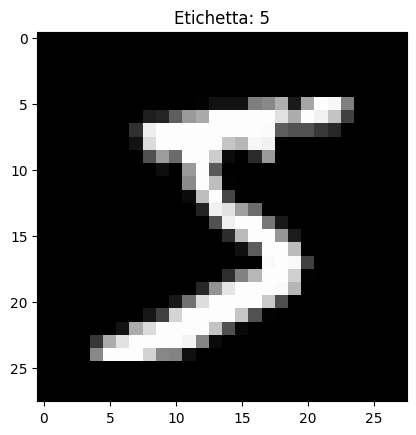

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

# Caricamento del dataset MNIST

(X_train, y_train), (X_test, y_test) = mnist.load_data()


# Visualizzazione di un esempio

plt.imshow(X_train[0], cmap='gray')

plt.title(f'Etichetta: {y_train[0]}')

plt.show()


# Normalizzazione dei dati

X_train = X_train.astype('float32') / 255

X_test = X_test.astype('float32') / 255


# Reshape dei dati

X_train = X_train.reshape(-1, 28*28)

X_test = X_test.reshape(-1, 28*28)


# Conversione delle etichette in formato one-hot encoding

y_train = to_categorical(y_train, num_classes=10)

y_test = to_categorical(y_test, num_classes=10)

In [4]:
# Creazione del modello

model = Sequential()


# Aggiunta degli strati

model.add(Dense(units=128, activation='relu', input_shape=(784,)))
model.add(Dropout(0.3))

model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(units=10, activation='softmax'))

C:\Users\veryv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
opt = Adam(learning_rate=0.001)

In [7]:
model.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [8]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Stop training if val_loss doesn't improve for 7 epochs
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True,
    verbose=1
)

# 2. Halve the Learning Rate if val_loss doesn't improve for 3 epochs
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,      # Factor by which the learning rate will be reduced (0.5 = half)
    patience=3,      # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-6,     # Lower bound on the learning rate
    verbose=1
)

In [9]:
history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=64,
                    validation_split=0.1,
                    callbacks=[early_stop, reduce_lr]) # non superare 128 di batch size

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8557 - loss: 0.4762 - val_accuracy: 0.9565 - val_loss: 0.1494 - learning_rate: 0.0010
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9326 - loss: 0.2294 - val_accuracy: 0.9690 - val_loss: 0.1068 - learning_rate: 0.0010
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9465 - loss: 0.1812 - val_accuracy: 0.9742 - val_loss: 0.0902 - learning_rate: 0.0010
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9551 - loss: 0.1537 - val_accuracy: 0.9745 - val_loss: 0.0836 - learning_rate: 0.0010
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9607 - loss: 0.1337 - val_accuracy: 0.9752 - val_loss: 0.0845 - learning_rate: 0.0010
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9626 - loss: 0.1229 - val_accuracy: 0.9783 - val_loss: 0.0759 - learning_rate: 0.0010
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9661 - loss: 0.1125 -

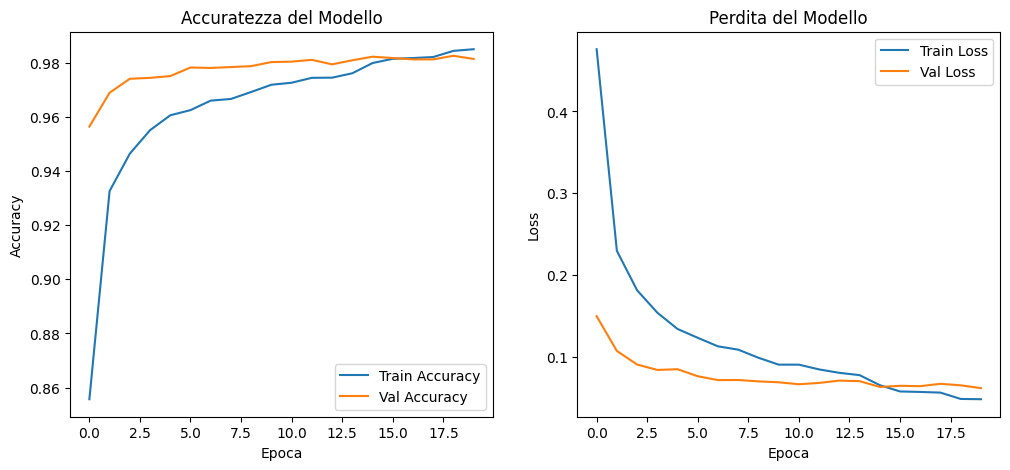

In [10]:
import matplotlib.pyplot as plt

# Creiamo una figura con due grafici (Sottoplot)
plt.figure(figsize=(12, 5))

# Grafico della Precisione (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuratezza del Modello')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

# Grafico della Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Perdita del Modello')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f'Perdita sul test set: {test_loss:.4f}')

print(f'Accuratezza sul test set: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9819 - loss: 0.0727
Perdita sul test set: 0.0727
Accuratezza sul test set: 0.9819


# Convoluzionali

In [12]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import numpy as np
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, Input
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


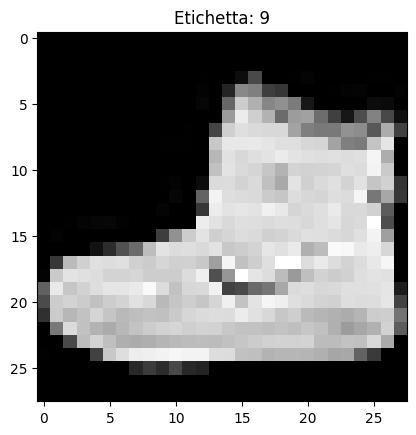

In [13]:
# 1. Caricamento del dataset Fashion MNIST
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Visualizzazione di un esempio (Capi di abbigliamento invece di cifre)
plt.imshow(X_train[0], cmap='gray')
plt.title(f'Etichetta: {y_train[0]}')
plt.show()

# 2. Normalizzazione
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# 3. Reshape per CNN (Samples, Height, Width, Channels)
# Per le CNN serve la dimensione del canale (1 per scala di grigi)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Conversione delle etichette in formato one-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [14]:
# 4. Creazione del modello Convoluzionale
model = Sequential()

# Input layer (scelta consigliata da Keras 3 invece di input_shape nei layer)
model.add(Input(shape=(28, 28, 1)))

# Primo blocco convoluzionale: estrazione caratteristiche spaziali
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu')) # quello che crea la matrice di trasformazione
model.add(MaxPooling2D(pool_size=(2, 2)))

# Secondo blocco convoluzionale
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Appiattimento e strati densi (simili al tuo codice originale)
model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=10, activation='softmax'))

In [15]:
# 5. Sommario e Compilazione
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,650 (908.79 KB)

 Trainable params: 232,650 (908.79 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
opt = Adam(learning_rate=0.001)
model.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
# 6. Callbacks (identici all'originale)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [18]:
# 7. Addestramento
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=64,
                    validation_split=0.1,
                    callbacks=[early_stop, reduce_lr])

Epoch 1/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.7629 - loss: 0.6609 - val_accuracy: 0.8570 - val_loss: 0.3814 - learning_rate: 0.0010
Epoch 2/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - accuracy: 0.8542 - loss: 0.4056 - val_accuracy: 0.8825 - val_loss: 0.3229 - learning_rate: 0.0010
Epoch 3/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.8780 - loss: 0.3441 - val_accuracy: 0.8823 - val_loss: 0.3065 - learning_rate: 0.0010
Epoch 4/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.8880 - loss: 0.3101 - val_accuracy: 0.8880 - val_loss: 0.2908 - learning_rate: 0.0010
Epoch 5/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.8974 - loss: 0.2838 - val_accuracy: 0.8978 - val_loss: 0.2698 - learning_rate: 0.0010
Epoch 6/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9056 - loss: 0.2621 - val_accuracy: 0.9080 - val_loss: 0.2432 - learning_rate: 0.0010
Epoch 7/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.9

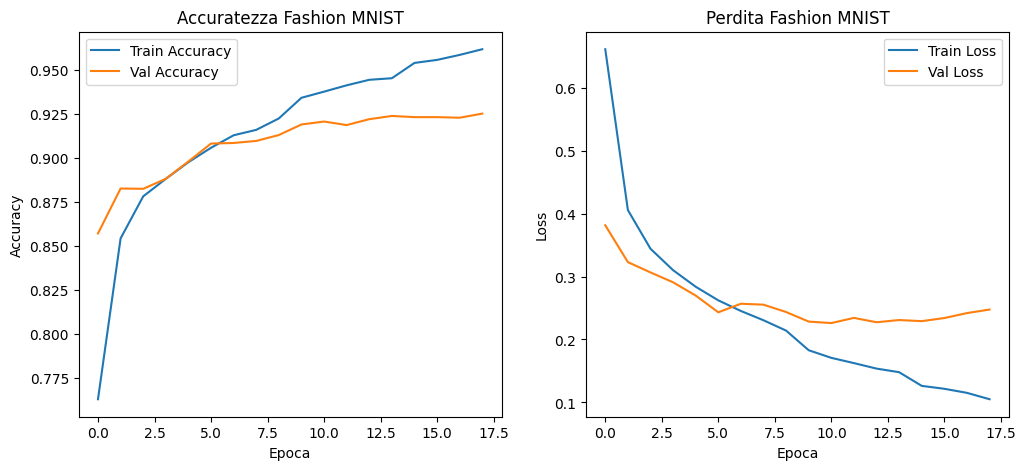

In [19]:
# 8. Visualizzazione Risultati
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuratezza Fashion MNIST')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Perdita Fashion MNIST')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [20]:
# 9. Valutazione finale
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Perdita sul test set: {test_loss:.4f}')
print(f'Accuratezza sul test set: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9151 - loss: 0.2481
Perdita sul test set: 0.2481
Accuratezza sul test set: 0.9151


In [21]:
import datetime
from keras.callbacks import TensorBoard

# 1. Setup the log directory
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# 2. Define the callback
# histogram_freq=1 allows you to see the weights changing in each layer
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# 3. Add it to your model.fit (using the Fashion MNIST CNN from before)
history = model.fit(
    X_train, y_train,
    epochs=10, 
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr, tensorboard_callback] # <--- Added here
)



Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.9469 - loss: 0.1470 - val_accuracy: 0.9230 - val_loss: 0.2208 - learning_rate: 1.2500e-04
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.9479 - loss: 0.1403 - val_accuracy: 0.9245 - val_loss: 0.2272 - learning_rate: 1.2500e-04
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9502 - loss: 0.1367 - val_accuracy: 0.9240 - val_loss: 0.2196 - learning_rate: 1.2500e-04
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9520 - loss: 0.1325 - val_accuracy: 0.9245 - val_loss: 0.2262 - learning_rate: 1.2500e-04
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9526 - loss: 0.1313 - val_accuracy: 0.9262 - val_loss: 0.2222 - learning_rate: 1.2500e-04
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9543 - loss: 0.1249
Epoch 6: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - acc

In [22]:
!tensorboard --logdir logs # si apre su http://localhost:6006

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\veryv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\Scripts\tensorboard.exe\__main__.py", line 4, in <module>
  File "C:\Users\veryv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "C:\Users\veryv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tensorboard\default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'


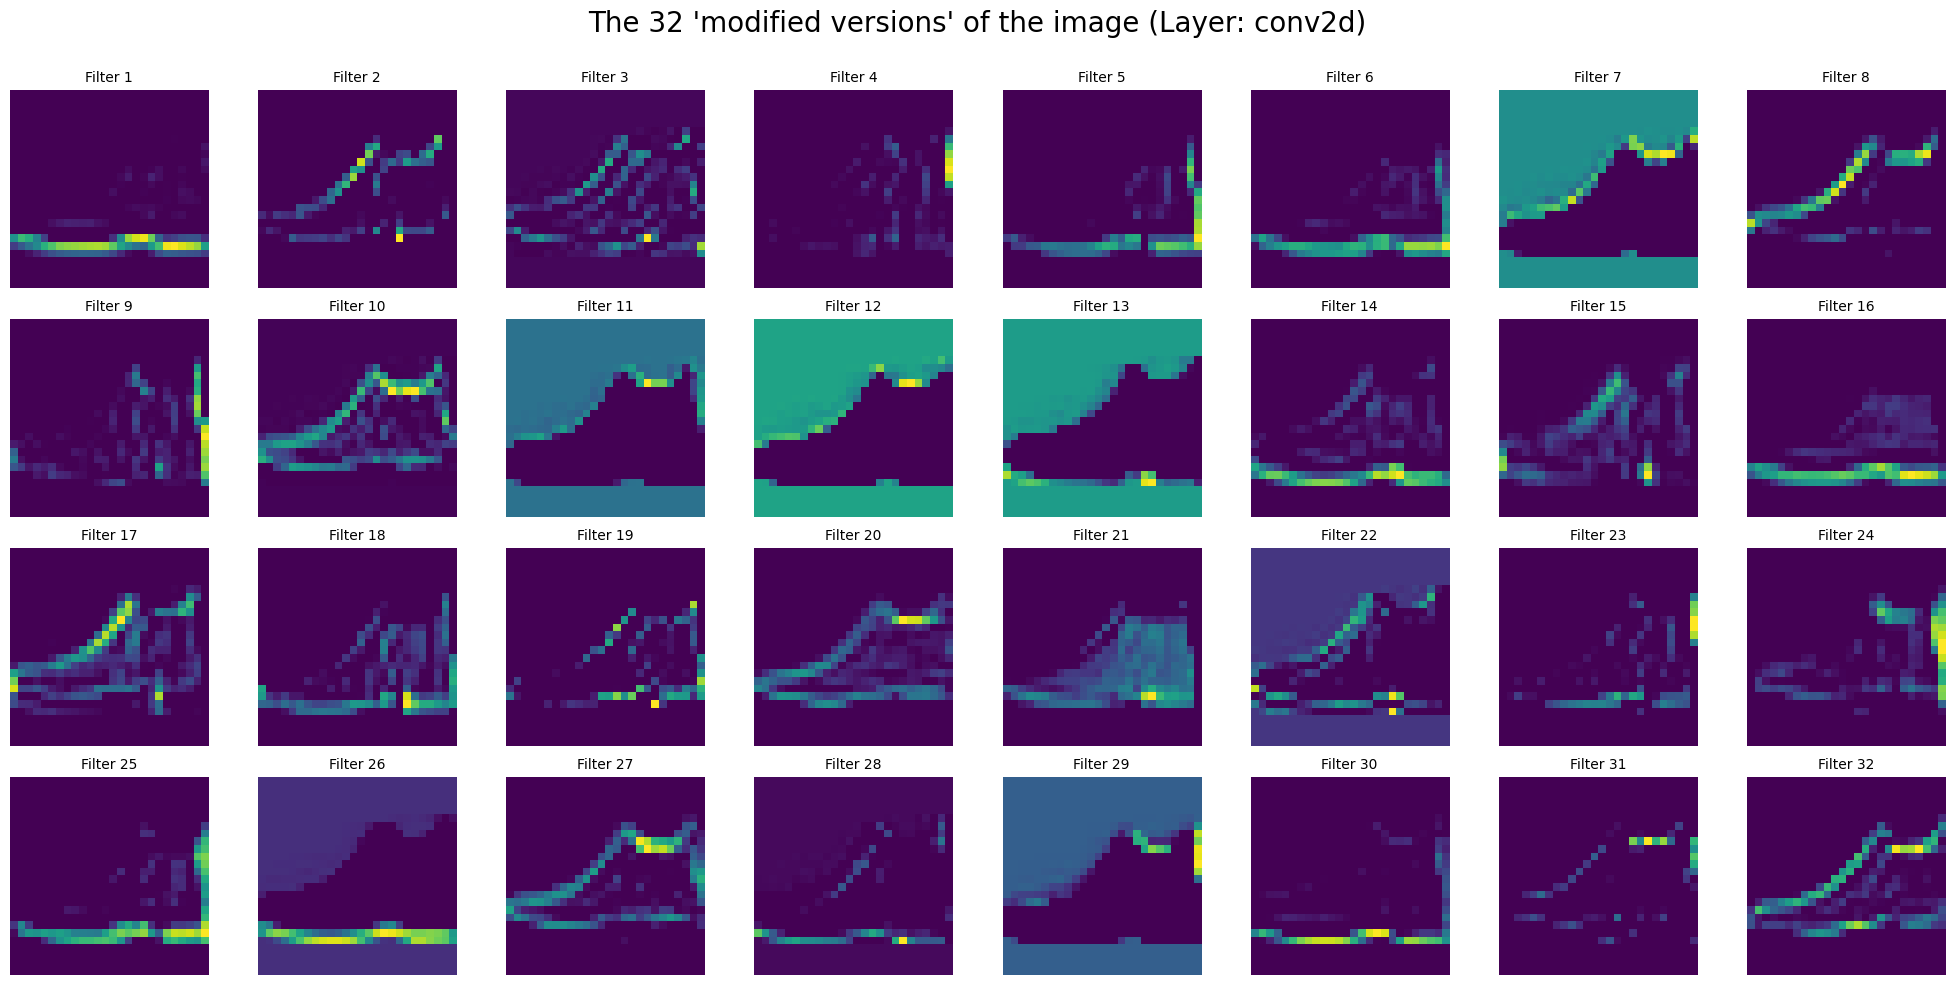

In [23]:
import keras
from keras.models import Model
import matplotlib.pyplot as plt
import numpy as np

def plot_first_layer_feature_maps(trained_model, input_image):
    # 1. Find the first Conv2D layer
    first_conv_layer = None
    for layer in trained_model.layers:
        if 'conv2d' in layer.name:
            first_conv_layer = layer
            break
            
    if first_conv_layer is None:
        print("Error: No Conv2D layer found.")
        return

    # 2. Build a functional model explicitly for visualization
    # This avoids the "layer not called" error by creating a new path
    img_input = keras.Input(shape=(28, 28, 1))
    x = first_conv_layer(img_input)
    activation_model = Model(inputs=img_input, outputs=x)
    
    # 3. Prepare the single image
    # Ensure image is (28, 28, 1) and add batch dim -> (1, 28, 28, 1)
    img_tensor = np.expand_dims(input_image, axis=0)
    
    # 4. Generate the 32 "modified versions"
    feature_maps = activation_model.predict(img_tensor, verbose=0)
    
    # 5. Plotting
    plt.figure(figsize=(20, 10))
    for i in range(32):
        plt.subplot(4, 8, i + 1)
        # We take the i-th filter from the first image in batch
        plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
        plt.axis('off')
        plt.title(f"Filter {i+1}", fontsize=10)
    
    plt.suptitle(f"The 32 'modified versions' of the image (Layer: {first_conv_layer.name})", fontsize=20)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

# Run it
plot_first_layer_feature_maps(model, X_test[0])